# UJIAN TENGAH SEMESTER
## FISIKA KOMPUTASI LANJUT
### Ardiansah Nur Rohman
### 230322607922

Selesaikan Secara numerik dengan metode euler eksplisit, implisit dan RK4 untuk ayunan sederhana dimana kondisi awal bandul berada di posisi di keseimbangan dan bandul memiliki kecepatan awal $\omega 0 = 1 rad/s$. Gunakan $g = 10 m/s^2$. Adapain persamaan ayunan bandul adalah sebagai berikut :

$$
\frac{d^2\theta}{dt^2} = \frac{-g}{l} sin(\theta)
$$

Anggaplah sudut ayunan kecil sehingga $sin(\theta) \approx \theta$/

![Bandul](bandul.jpg)
 


a. Turunkan Persamaan Diferensial Numerikanya (FDE)\
b. Cari nilai $\Delta t$ sesuai dengan syarat CFL\
Buat Program Python dan ditulis dalam format Jupyter Notebook.\
c. Gambar grafik analitis, metode eksplisit, implisit, dan RK4\
d. Gambar grafik galat masing-masing di gambar terpisah.\
e. Tuliskan Semua Jawaban (Termasuk a dan b) dalam format Jupyter Notebook dan di upload di Sipejar

*Jawaban Soal (a) dan (b)*

*(a) Penurunan Rumus Persamaan Gerak dan Metode Numerik*
Persamaan Gerak Bandul
$$
\frac{d^2\theta}{dt^2} = -\frac{g}{L}\sin(\theta)
$$
Untuk sudut kecil:
$$
\sin(\theta) \approx \theta
$$
Maka:
$$
\frac{d^2\theta}{dt^2} = -\frac{g}{L}\theta
$$

Definisikan:
$$
\omega = \frac{d\theta}{dt}
$$

Sehingga sistem:
$$
\frac{d\theta}{dt} = \omega
$$
$$
\frac{d\omega}{dt} = -\frac{g}{L}\theta
$$

---

*Metode Euler Maju*
$$
\frac{\theta_{n+1} - \theta_n}{\Delta t} = \omega_n
$$
$$
\frac{\omega_{n+1} - \omega_n}{\Delta t} = -\frac{g}{L}\theta_n
$$
$$
\boxed{
\begin{aligned}
\theta_{n+1} &= \theta_n + \omega_n \Delta t,\\[4pt]
\omega_{n+1} &= \omega_n - \frac{g}{L}\theta_n \Delta t
\end{aligned}
}
$$

---

*Metode Euler Belakang*
$$
\frac{\theta_{n+1} - \theta_n}{\Delta t} = \omega_{n+1}
$$
$$
\frac{\omega_{n+1} - \omega_n}{\Delta t} = -\frac{g}{L}\theta_{n+1}
$$
$$
\frac{\frac{\theta_{n+1} - \theta_n}{\Delta t} - \omega_n}{\Delta t} = -\frac{g}{L}\theta_{n+1}
$$
$$
\theta_{n+1} - \theta_n = \omega_n \Delta t - \frac{g}{L}\theta_{n+1}(\Delta t)^2
$$
$$
\theta_{n+1}\left(1 + \frac{g}{L}(\Delta t)^2\right) = \theta_n + \omega_n \Delta t
$$
$$
\boxed{
\theta_{n+1} = \frac{\theta_n + \omega_n \Delta t}{1 + \frac{g}{L}(\Delta t)^2}
}
$$
$$
\boxed{
\omega_{n+1} = \frac{\theta_{n+1} - \theta_n}{\Delta t}
}
$$

---

*Metode Runge–Kutta Orde 4*
$$
\frac{d\theta}{dt} = \omega
$$
$$
\frac{d\omega}{dt} = -\frac{g}{L}\theta
$$

$$
\begin{aligned}
k_1^\theta &= \omega_n, &k_1^\omega &= -\frac{g}{L}\theta_n,\\[4pt]
k_2^\theta &= \omega_n + \frac{\Delta t}{2}k_1^\omega, &k_2^\omega &= -\frac{g}{L}\left(\theta_n + \frac{\Delta t}{2}k_1^\theta\right),\\[4pt]
k_3^\theta &= \omega_n + \frac{\Delta t}{2}k_2^\omega, &k_3^\omega &= -\frac{g}{L}\left(\theta_n + \frac{\Delta t}{2}k_2^\theta\right),\\[4pt]
k_4^\theta &= \omega_n + \Delta t\,k_3^\omega, &k_4^\omega &= -\frac{g}{L}\left(\theta_n + \Delta t\,k_3^\theta\right)
\end{aligned}
$$

$$
\boxed{
\begin{aligned}
\theta_{n+1} &= \theta_n + \frac{\Delta t}{6}(k_1^\theta + 2k_2^\theta + 2k_3^\theta + k_4^\theta),\\[4pt]
\omega_{n+1} &= \omega_n + \frac{\Delta t}{6}(k_1^\omega + 2k_2^\omega + 2k_3^\omega + k_4^\omega)
\end{aligned}
}
$$

---

*(b) Batas Waktu Langkah (Δt) agar Stabil*

Persamaan:
$$
\frac{d^2\theta}{dt^2} + \omega_0^2 \theta = 0
$$

Dengan:
$$
\omega_0 = \sqrt{\frac{g}{L}}
$$

Syarat stabilitas metode eksplisit:
$$
\omega_0 \Delta t < 2
$$

Substitusi:
$$
\sqrt{\frac{g}{L}} \Delta t < 2
$$

Maka:
$$
\boxed{
\Delta t < \frac{2}{\sqrt{\frac{g}{L}}}
}
$$

Buat Program Python dan Ditulis dalam FOrmat Jupyter Notebook\
a. Gambar Grafik Analitis, metode eksplisit, implisit, dan RK4

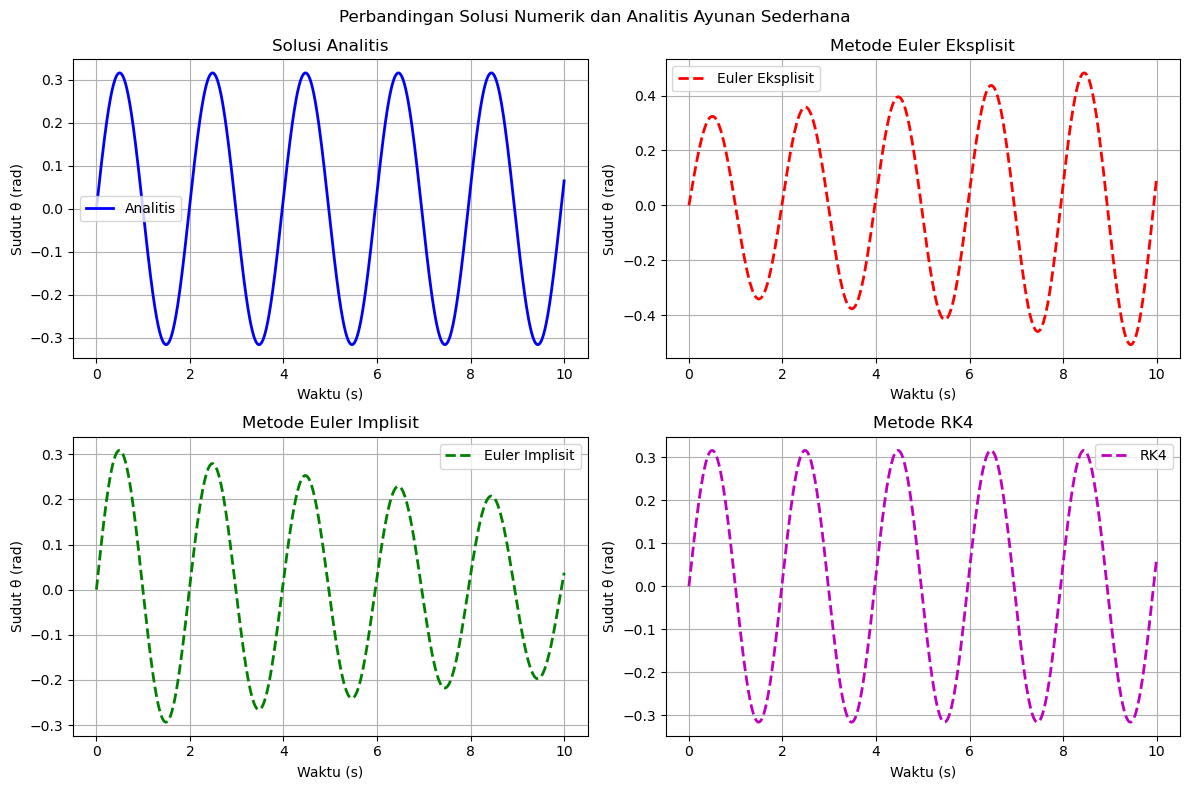

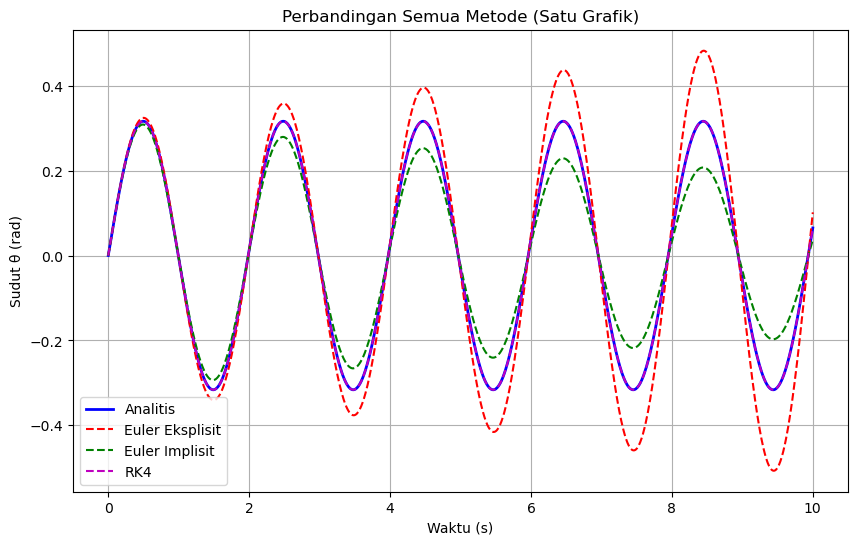

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter fisika
g = 10.0
l = 1.0
omega_0 = np.sqrt(g / l)

# Kondisi awal
theta0 = 0.0
omega_initial = 1.0

# Waktu simulasi
t_start = 0.0
t_end = 10.0
dt = 0.01
num_steps = int((t_end - t_start) / dt)
t = np.linspace(t_start, t_end, num_steps + 1)

# Solusi analitis
A_analytical = 0.0
B_analytical = omega_initial / omega_0
theta_analytical = A_analytical * np.cos(omega_0 * t) + B_analytical * np.sin(omega_0 * t)

# Euler eksplisit
theta_explicit = np.zeros(num_steps + 1)
omega_explicit = np.zeros(num_steps + 1)
theta_explicit[0] = theta0
omega_explicit[0] = omega_initial

for i in range(num_steps):
    dtheta_dt = omega_explicit[i]
    domega_dt = - (g / l) * theta_explicit[i]
    theta_explicit[i+1] = theta_explicit[i] + dt * dtheta_dt
    omega_explicit[i+1] = omega_explicit[i] + dt * domega_dt

# Euler implisit
theta_implicit = np.zeros(num_steps + 1)
omega_implicit = np.zeros(num_steps + 1)
theta_implicit[0] = theta0
omega_implicit[0] = omega_initial

for i in range(num_steps):
    denom = 1 + (g / l) * dt**2
    theta_implicit[i+1] = (theta_implicit[i] + dt * omega_implicit[i]) / denom
    omega_implicit[i+1] = omega_implicit[i] - (g / l) * dt * theta_implicit[i+1]

# RK4
theta_rk4 = np.zeros(num_steps + 1)
omega_rk4 = np.zeros(num_steps + 1)
theta_rk4[0] = theta0
omega_rk4[0] = omega_initial

def f_theta(omega):
    return omega

def f_omega(theta):
    return - (g / l) * theta

for i in range(num_steps):
    k1_theta = f_theta(omega_rk4[i])
    k1_omega = f_omega(theta_rk4[i])
    
    k2_theta = f_theta(omega_rk4[i] + dt/2 * k1_omega)
    k2_omega = f_omega(theta_rk4[i] + dt/2 * k1_theta)
    
    k3_theta = f_theta(omega_rk4[i] + dt/2 * k2_omega)
    k3_omega = f_omega(theta_rk4[i] + dt/2 * k2_theta)
    
    k4_theta = f_theta(omega_rk4[i] + dt * k3_omega)
    k4_omega = f_omega(theta_rk4[i] + dt * k3_theta)
    
    theta_rk4[i+1] = theta_rk4[i] + dt/6 * (k1_theta + 2*k2_theta + 2*k3_theta + k4_theta)
    omega_rk4[i+1] = omega_rk4[i] + dt/6 * (k1_omega + 2*k2_omega + 2*k3_omega + k4_omega)

# Plot grafik terpisah
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Perbandingan Solusi Numerik dan Analitis Ayunan Sederhana')

axes[0, 0].plot(t, theta_analytical, 'b-', linewidth=2, label='Analitis')
axes[0, 0].set_title('Solusi Analitis')
axes[0, 0].set_xlabel('Waktu (s)')
axes[0, 0].set_ylabel('Sudut θ (rad)')
axes[0, 0].grid(True)
axes[0, 0].legend()

axes[0, 1].plot(t, theta_explicit, 'r--', linewidth=2, label='Euler Eksplisit')
axes[0, 1].set_title('Metode Euler Eksplisit')
axes[0, 1].set_xlabel('Waktu (s)')
axes[0, 1].set_ylabel('Sudut θ (rad)')
axes[0, 1].grid(True)
axes[0, 1].legend()

axes[1, 0].plot(t, theta_implicit, 'g--', linewidth=2, label='Euler Implisit')
axes[1, 0].set_title('Metode Euler Implisit')
axes[1, 0].set_xlabel('Waktu (s)')
axes[1, 0].set_ylabel('Sudut θ (rad)')
axes[1, 0].grid(True)
axes[1, 0].legend()

axes[1, 1].plot(t, theta_rk4, 'm--', linewidth=2, label='RK4')
axes[1, 1].set_title('Metode RK4')
axes[1, 1].set_xlabel('Waktu (s)')
axes[1, 1].set_ylabel('Sudut θ (rad)')
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Plot semua dalam satu grafik (opsional)
plt.figure(figsize=(10, 6))
plt.plot(t, theta_analytical, 'b-', linewidth=2, label='Analitis')
plt.plot(t, theta_explicit, 'r--', linewidth=1.5, label='Euler Eksplisit')
plt.plot(t, theta_implicit, 'g--', linewidth=1.5, label='Euler Implisit')
plt.plot(t, theta_rk4, 'm--', linewidth=1.5, label='RK4')
plt.title('Perbandingan Semua Metode (Satu Grafik)')
plt.xlabel('Waktu (s)')
plt.ylabel('Sudut θ (rad)')
plt.legend()
plt.grid(True)
plt.show()

d. Gambar Grafik galat masing-masing di gambar terpisah

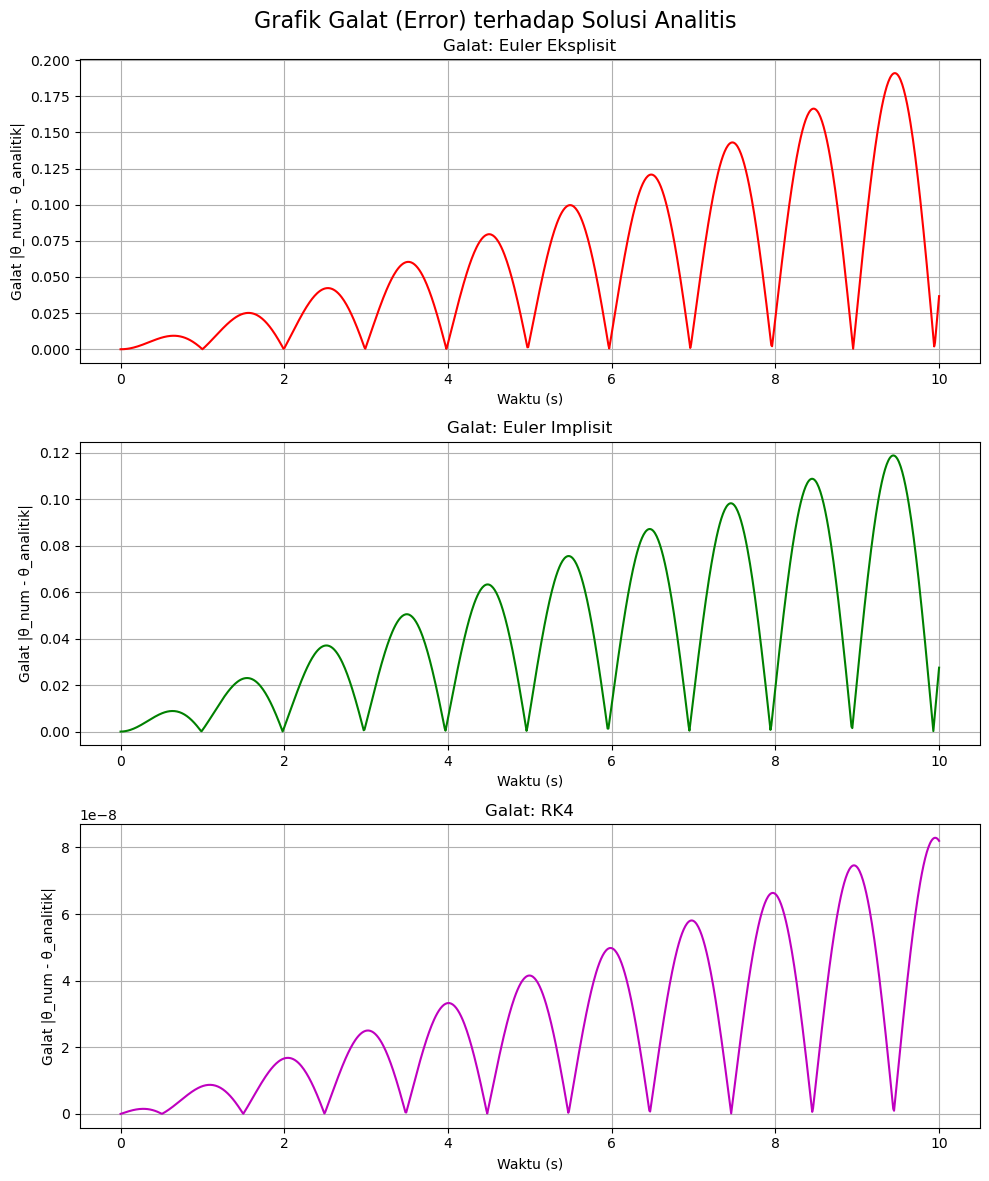

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter fisika
g = 10.0
l = 1.0
omega_0 = np.sqrt(g / l)

# Kondisi awal
theta0 = 0.0
omega_initial = 1.0

# Waktu simulasi
t_start = 0.0
t_end = 10.0
dt = 0.01
num_steps = int((t_end - t_start) / dt)
t = np.linspace(t_start, t_end, num_steps + 1)

# Solusi analitis
A_analytical = 0.0
B_analytical = omega_initial / omega_0
theta_analytical = A_analytical * np.cos(omega_0 * t) + B_analytical * np.sin(omega_0 * t)

# Euler eksplisit
theta_explicit = np.zeros(num_steps + 1)
omega_explicit = np.zeros(num_steps + 1)
theta_explicit[0] = theta0
omega_explicit[0] = omega_initial

for i in range(num_steps):
    dtheta_dt = omega_explicit[i]
    domega_dt = - (g / l) * theta_explicit[i]
    theta_explicit[i+1] = theta_explicit[i] + dt * dtheta_dt
    omega_explicit[i+1] = omega_explicit[i] + dt * domega_dt

# Euler implisit
theta_implicit = np.zeros(num_steps + 1)
omega_implicit = np.zeros(num_steps + 1)
theta_implicit[0] = theta0
omega_implicit[0] = omega_initial

for i in range(num_steps):
    denom = 1 + (g / l) * dt**2
    theta_implicit[i+1] = (theta_implicit[i] + dt * omega_implicit[i]) / denom
    omega_implicit[i+1] = omega_implicit[i] - (g / l) * dt * theta_implicit[i+1]

# RK4
theta_rk4 = np.zeros(num_steps + 1)
omega_rk4 = np.zeros(num_steps + 1)
theta_rk4[0] = theta0
omega_rk4[0] = omega_initial

def f_theta(omega):
    return omega

def f_omega(theta):
    return - (g / l) * theta

for i in range(num_steps):
    k1_theta = f_theta(omega_rk4[i])
    k1_omega = f_omega(theta_rk4[i])
    
    k2_theta = f_theta(omega_rk4[i] + dt/2 * k1_omega)
    k2_omega = f_omega(theta_rk4[i] + dt/2 * k1_theta)
    
    k3_theta = f_theta(omega_rk4[i] + dt/2 * k2_omega)
    k3_omega = f_omega(theta_rk4[i] + dt/2 * k2_theta)
    
    k4_theta = f_theta(omega_rk4[i] + dt * k3_omega)
    k4_omega = f_omega(theta_rk4[i] + dt * k3_theta)
    
    theta_rk4[i+1] = theta_rk4[i] + dt/6 * (k1_theta + 2*k2_theta + 2*k3_theta + k4_theta)
    omega_rk4[i+1] = omega_rk4[i] + dt/6 * (k1_omega + 2*k2_omega + 2*k3_omega + k4_omega)

# Hitung galat absolut
error_explicit = np.abs(theta_explicit - theta_analytical)
error_implicit = np.abs(theta_implicit - theta_analytical)
error_rk4 = np.abs(theta_rk4 - theta_analytical)

# Plot galat masing-masing dalam grafik terpisah
fig, axes = plt.subplots(3, 1, figsize=(10, 12))
fig.suptitle('Grafik Galat (Error) terhadap Solusi Analitis', fontsize=16)

# Galat Euler Eksplisit
axes[0].plot(t, error_explicit, 'r-', linewidth=1.5)
axes[0].set_title('Galat: Euler Eksplisit')
axes[0].set_xlabel('Waktu (s)')
axes[0].set_ylabel('Galat |θ_num - θ_analitik|')
axes[0].grid(True)

# Galat Euler Implisit
axes[1].plot(t, error_implicit, 'g-', linewidth=1.5)
axes[1].set_title('Galat: Euler Implisit')
axes[1].set_xlabel('Waktu (s)')
axes[1].set_ylabel('Galat |θ_num - θ_analitik|')
axes[1].grid(True)

# Galat RK4
axes[2].plot(t, error_rk4, 'm-', linewidth=1.5)
axes[2].set_title('Galat: RK4')
axes[2].set_xlabel('Waktu (s)')
axes[2].set_ylabel('Galat |θ_num - θ_analitik|')
axes[2].grid(True)

plt.tight_layout()
plt.show()